In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from my_nn import activations, loss, metrics, nn
from data.sample_data import generate_data, plot_data

In [2]:
# first get the data
data, targets = generate_data(seed=42)

#### For this notebook we will be looking at the binary classification using the target defined by the parabolic boundary.

In [10]:
# set up X, y for training
# use numpy arrays here for now so train test split works properly
X = np.array(data[["x1","x2"]])
y = np.array(data["binary_parabola"])
data_used = data[["x1","x2","binary_parabola"]].copy()

In [11]:
# do a train_test split
X_train, X_test, y_train, y_test = nn.train_test_split(X, y, test_size = 0.2, random_state=42)

In [13]:
# create 3 versions of the model to train. These will be identical here, and will only differ in how the .fit() is called
model_sgd = nn.FeedForward(
    nn.Dense(2, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 1, activation="sigmoid")
)

model_momentum = nn.FeedForward(
    nn.Dense(2, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 1, activation="sigmoid")
)

model_adam = nn.FeedForward(
    nn.Dense(2, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 30, activation="relu"),
    nn.Dense(30, 1, activation="sigmoid")
)

In [14]:
# train the models
history_sgd = model_sgd.fit(
    X_train,
    y_train,
    epochs=200,
    learning_rate=0.01,
    batch_size=32,
    verbose=False,
    loss_fn="binary_cross_entropy",
    metric="accuracy",
    val_size = 0.2,
    optimizer="sgd"
)

Epoch 1 complete. Average Loss: 0.6515 , accuracy 0.7936 -  Validation Loss: 0.4068, Validation accuracy 0.7812
Epoch 2 complete. Average Loss: 0.3568 , accuracy 0.7989 -  Validation Loss: 0.3573, Validation accuracy 0.7837
Epoch 3 complete. Average Loss: 0.3268 , accuracy 0.8206 -  Validation Loss: 0.3356, Validation accuracy 0.8069
Epoch 4 complete. Average Loss: 0.3103 , accuracy 0.8459 -  Validation Loss: 0.3216, Validation accuracy 0.8294
Epoch 5 complete. Average Loss: 0.2988 , accuracy 0.8673 -  Validation Loss: 0.3115, Validation accuracy 0.8581
Epoch 6 complete. Average Loss: 0.2901 , accuracy 0.8812 -  Validation Loss: 0.3035, Validation accuracy 0.8669
Epoch 7 complete. Average Loss: 0.2830 , accuracy 0.8942 -  Validation Loss: 0.2969, Validation accuracy 0.8762
Epoch 8 complete. Average Loss: 0.2770 , accuracy 0.9005 -  Validation Loss: 0.2911, Validation accuracy 0.8825
Epoch 9 complete. Average Loss: 0.2718 , accuracy 0.9034 -  Validation Loss: 0.2861, Validation accuracy

In [15]:
history_momentum = model_momentum.fit(
    X_train,
    y_train,
    epochs=200,
    learning_rate=0.01,
    batch_size=32,
    verbose=False,
    loss_fn="binary_cross_entropy",
    metric="accuracy",
    val_size = 0.2,
    optimizer="momentum"
)

Epoch 1 complete. Average Loss: 0.5398 , accuracy 0.9014 -  Validation Loss: 0.3517, Validation accuracy 0.8969
Epoch 2 complete. Average Loss: 0.3250 , accuracy 0.8909 -  Validation Loss: 0.3090, Validation accuracy 0.8850
Epoch 3 complete. Average Loss: 0.2938 , accuracy 0.8952 -  Validation Loss: 0.2855, Validation accuracy 0.8944
Epoch 4 complete. Average Loss: 0.2733 , accuracy 0.9005 -  Validation Loss: 0.2684, Validation accuracy 0.8988
Epoch 5 complete. Average Loss: 0.2581 , accuracy 0.9016 -  Validation Loss: 0.2554, Validation accuracy 0.9000
Epoch 6 complete. Average Loss: 0.2463 , accuracy 0.9031 -  Validation Loss: 0.2453, Validation accuracy 0.8981
Epoch 7 complete. Average Loss: 0.2369 , accuracy 0.9038 -  Validation Loss: 0.2372, Validation accuracy 0.8988
Epoch 8 complete. Average Loss: 0.2294 , accuracy 0.9038 -  Validation Loss: 0.2308, Validation accuracy 0.8988
Epoch 9 complete. Average Loss: 0.2232 , accuracy 0.9036 -  Validation Loss: 0.2255, Validation accuracy

In [16]:
history_adam = model_adam.fit(
    X_train,
    y_train,
    epochs=200,
    learning_rate=0.01,
    batch_size=32,
    verbose=False,
    loss_fn="binary_cross_entropy",
    metric="accuracy",
    val_size = 0.2,
    optimizer="adam"
)

Epoch 1 complete. Average Loss: 0.1150 , accuracy 0.9788 -  Validation Loss: 0.0630, Validation accuracy 0.9719
Epoch 2 complete. Average Loss: 0.0405 , accuracy 0.9825 -  Validation Loss: 0.0443, Validation accuracy 0.9812
Epoch 3 complete. Average Loss: 0.0388 , accuracy 0.9836 -  Validation Loss: 0.0498, Validation accuracy 0.9769
Epoch 4 complete. Average Loss: 0.0314 , accuracy 0.9866 -  Validation Loss: 0.0465, Validation accuracy 0.9794
Epoch 5 complete. Average Loss: 0.0279 , accuracy 0.9841 -  Validation Loss: 0.0337, Validation accuracy 0.9825
Epoch 6 complete. Average Loss: 0.0300 , accuracy 0.9869 -  Validation Loss: 0.0470, Validation accuracy 0.9819
Epoch 7 complete. Average Loss: 0.0231 , accuracy 0.9869 -  Validation Loss: 0.0386, Validation accuracy 0.9844
Epoch 8 complete. Average Loss: 0.0229 , accuracy 0.9939 -  Validation Loss: 0.0182, Validation accuracy 0.9938
Epoch 9 complete. Average Loss: 0.0223 , accuracy 0.9964 -  Validation Loss: 0.0155, Validation accuracy

c:\Users\ronsp\IdeaProjects\neural_networks\my_nn\activations.py:28: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


Epoch 199 complete. Average Loss: 0.0073 , accuracy 0.9970 -  Validation Loss: 0.0144, Validation accuracy 0.9944
Epoch 200 complete. Average Loss: 0.0095 , accuracy 0.9927 -  Validation Loss: 0.0198, Validation accuracy 0.9919


#### Let's look at the histories of each

##### First for standard gradient descent

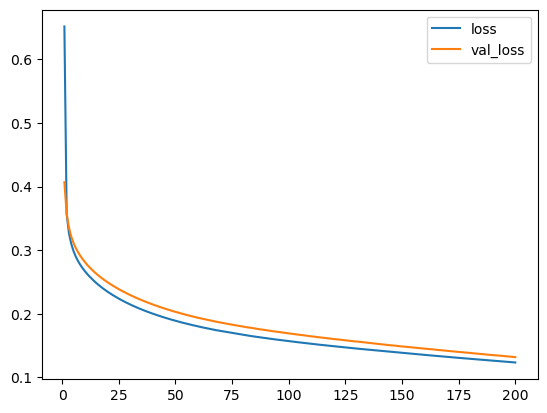

In [17]:
nn.plot_history(history_sgd, "loss", "val_loss")

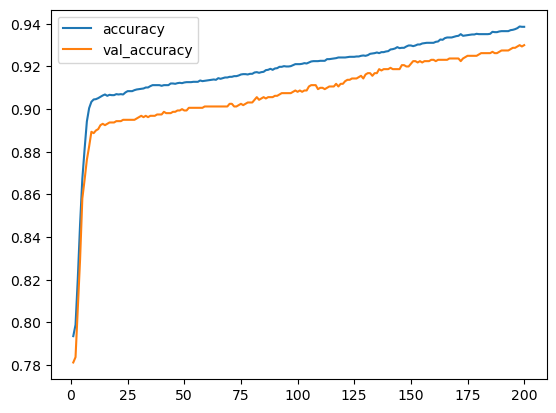

In [18]:
nn.plot_history(history_sgd, "accuracy", "val_accuracy")

##### Next for momentum

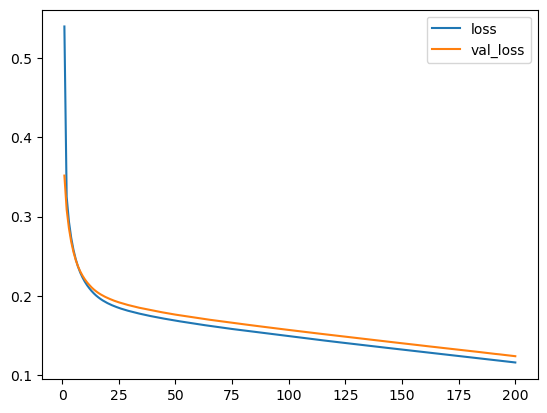

In [19]:
nn.plot_history(history_momentum, "loss", "val_loss")

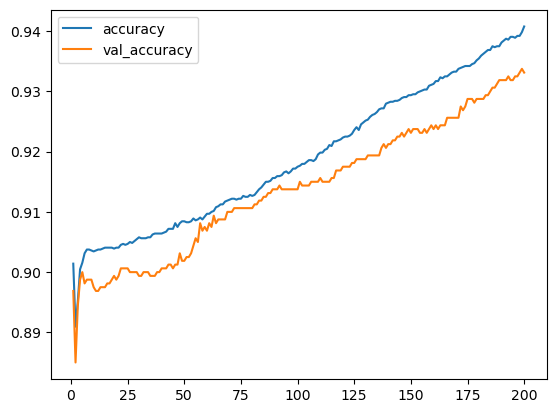

In [20]:
nn.plot_history(history_momentum, "accuracy", "val_accuracy")

In [21]:
##### Finally for adam

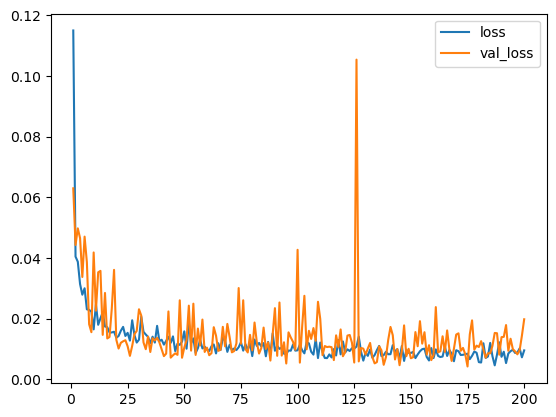

In [22]:
nn.plot_history(history_adam, "loss", "val_loss")

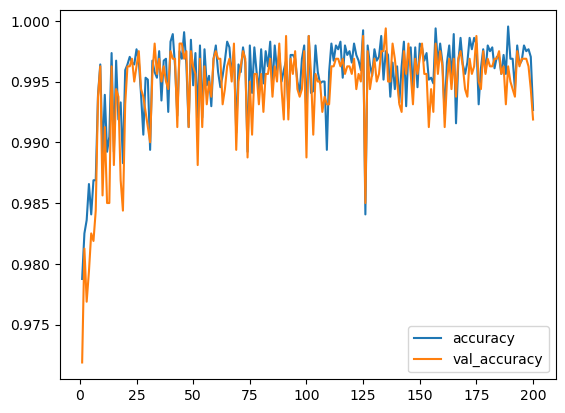

In [23]:
nn.plot_history(history_adam, "accuracy", "val_accuracy")

#### Now lets see how these do on the unseen test data

In [24]:
y_pred_sgd = model_sgd.predict(X_test)
y_pred_momentum = model_momentum.predict(X_test)
y_pred_adam = model_adam.predict(X_test)

In [28]:
print("SGD all real numbers: ", np.isfinite(y_pred_sgd).all())
print("Momentum all real numbers: ",np.isfinite(y_pred_momentum).all())
print("Adam all real numbers: ", np.isfinite(y_pred_adam).all())

SGD all real numbers:  True
Momentum all real numbers:  True
Adam all real numbers:  True


In [29]:
# convert to 0,1 for use in metrics
y_labels_sgd = (y_pred_sgd >= 0.5).astype(int)
y_labels_momentum = (y_pred_momentum>=0.5).astype(int)
y_labels_adam = (y_pred_adam>=0.5).astype(int)

In [33]:
acc_sgd = metrics.accuracy(y_test, y_labels_sgd)
acc_mom = metrics.accuracy(y_test, y_labels_momentum)
acc_adam = metrics.accuracy(y_test, y_labels_adam)

precision_sgd = metrics.precision(y_test, y_labels_sgd)
precision_mom = metrics.precision(y_test, y_labels_momentum)
precision_adam = metrics.precision(y_test, y_labels_adam)

recall_sgd = metrics.recall(y_test, y_labels_sgd)
recall_mom = metrics.recall(y_test, y_labels_momentum)
recall_adam = metrics.recall(y_test, y_labels_adam)

f1_sgd = metrics.f1_score(y_test, y_labels_sgd)
f1_mom = metrics.f1_score(y_test, y_labels_momentum)
f1_adam = metrics.f1_score(y_test, y_labels_adam)

spec_sgd = metrics.specificity(y_test, y_labels_sgd)
spec_mom = metrics.specificity(y_test, y_labels_momentum)
spec_adam = metrics.specificity(y_test, y_labels_adam)

bal_acc_sgd = metrics.balanced_accuracy(y_test, y_labels_sgd)
bal_acc_mom = metrics.balanced_accuracy(y_test, y_labels_momentum)
bal_acc_adam = metrics.balanced_accuracy(y_test, y_labels_adam)

In [35]:
print("For Standard Gradient Descent")
print("-----------------------------")
print(f"Accuracy: {acc_sgd: .4f}")
print(f"Precision: {precision_sgd: .4f}")
print(f"Recall: {recall_sgd: .4f}")
print(f"F1 Score: {f1_sgd: .4f}")
print(f"Specificity: {spec_sgd: .4f}")
print(f"Balanced Accuracy: {bal_acc_sgd: .4f}")

For Standard Gradient Descent
-----------------------------
Accuracy:  0.9375
Precision:  0.7835
Recall:  0.9637
F1 Score:  0.8643
Specificity:  0.9307
Balanced Accuracy:  0.9472


In [36]:
print("For using momentum")
print("-----------------------------")
print(f"Accuracy: {acc_mom: .4f}")
print(f"Precision: {precision_mom: .4f}")
print(f"Recall: {recall_mom: .4f}")
print(f"F1 Score: {f1_mom: .4f}")
print(f"Specificity: {spec_mom: .4f}")
print(f"Balanced Accuracy: {bal_acc_mom: .4f}")

For using momentum
-----------------------------
Accuracy:  0.9425
Precision:  0.7953
Recall:  0.9735
F1 Score:  0.8754
Specificity:  0.9344
Balanced Accuracy:  0.9539


In [37]:
print("For Adam optimization")
print("-----------------------------")
print(f"Accuracy: {acc_adam: .4f}")
print(f"Precision: {precision_adam: .4f}")
print(f"Recall: {recall_adam: .4f}")
print(f"F1 Score: {f1_adam: .4f}")
print(f"Specificity: {spec_adam: .4f}")
print(f"Balanced Accuracy: {bal_acc_adam: .4f}")

For Adam optimization
-----------------------------
Accuracy:  0.9900
Precision:  0.9724
Recall:  0.9880
F1 Score:  0.9802
Specificity:  0.9907
Balanced Accuracy:  0.9893
